# Bank Marketing Campaign Prediction
This project aims to build a machine learning model that predicts whether a customer will subscribe to a term deposit based on marketing campaign data.

The dataset contains information about customers such as age, job, balance, previous marketing interactions, and communication details.

Using this data, we will explore patterns and build predictive models to help banks target customers who are more likely to subscribe.


## Problem Statement
Banks conduct marketing campaigns to encourage customers to subscribe to term deposits. However, contacting every customer is inefficient and expensive.

The goal of this project is to develop a machine learning model that predicts whether a customer will subscribe to a term deposit.

By identifying potential subscribers, the bank can focus marketing efforts on high-probability customers, reducing costs and improving campaign efficiency

## Summary
The Bank Marketing Campaign Prediction project aims to help banks identify customers who are more likely to subscribe to term deposits, improving campaign efficiency and reducing marketing costs. Using a dataset containing customer information such as age, job, balance, previous marketing interactions, and communication details, I performed extensive data preprocessing, including handling categorical features, converting binary variables to boolean, and applying one-hot encoding.

I addressed key challenges such as class imbalance by using threshold tuning and carefully selecting evaluation metrics like F1-score and recall to ensure accurate prediction of minority class subscribers. Feature selection and correlation analysis were also performed to reduce redundancy and improve model performance.

 The project demonstrates the application of machine learning to real-world marketing problems, enabling banks to focus efforts on high-probability customers and make data-driven decisions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BASIC CHECK

In [ ]:
data=pd.read_csv("bank-full.csv",sep=";")
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
data.shape

(45211, 17)

In [ ]:
data.size

768587

In [ ]:
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
data.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [ ]:
data.nunique()

,0
age,77
job,12
marital,3
education,4
default,2
balance,7168
housing,2
loan,2
contact,3
day,31


In [ ]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

## EDA

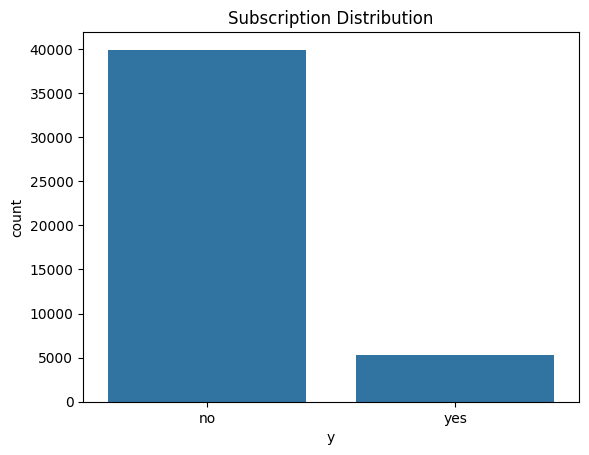

In [ ]:
# Most customers did not subscribe to the bank’s product, showing a low conversion rate. Targeted marketing could help improve subscriptions
sns.countplot(x='y', data=data)
plt.title("Subscription Distribution")
plt.show()

In [ ]:
data['y'].value_counts(normalize=True)*100

,proportion
y,
no,88.30152
yes,11.69848


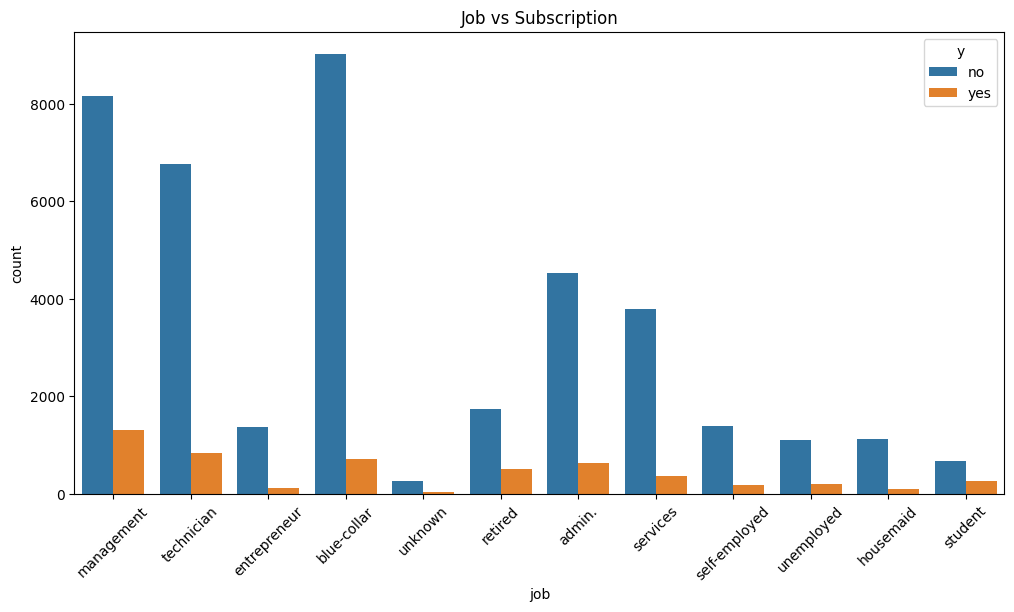

In [ ]:
# The subscription rates vary by job type. Some jobs, like [insert top jobs from your graph], show higher subscriptions,
# while others have mostly non-subscribers. This indicates that occupation influences the likelihood of subscribing,
# so marketing campaigns can be tailored to target job groups more likely to subscribe.
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=data)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()

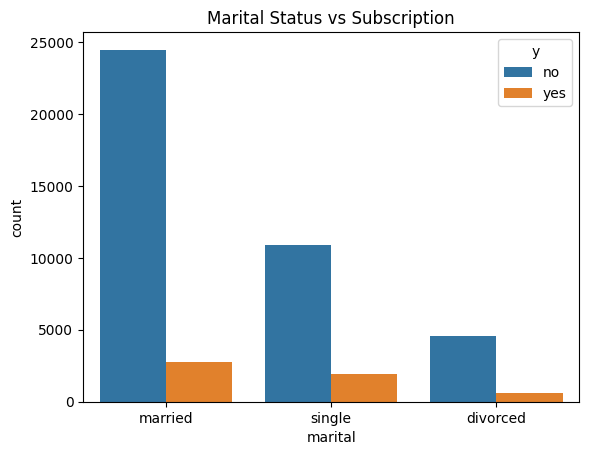

In [ ]:
# Subscription rates differ by marital status. Married customers tend to subscribe more than single
# or divorced ones, suggesting that marital status may influence a customer’s likelihood to invest in the bank’s product.
sns.countplot(x='marital', hue='y', data=data)
plt.title("Marital Status vs Subscription")
plt.show()

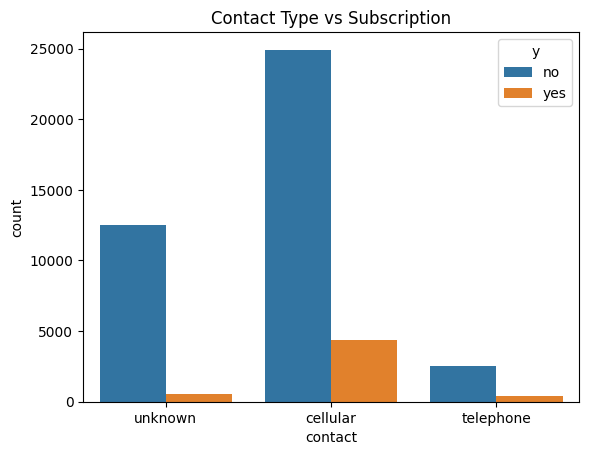

In [ ]:
# Customers contacted via cellular show higher subscription rates compared to those contacted by telephone,
# indicating that mobile outreach is more effective for product subscriptions.
sns.countplot(x='contact', hue='y', data=data)
plt.title("Contact Type vs Subscription")
plt.show()

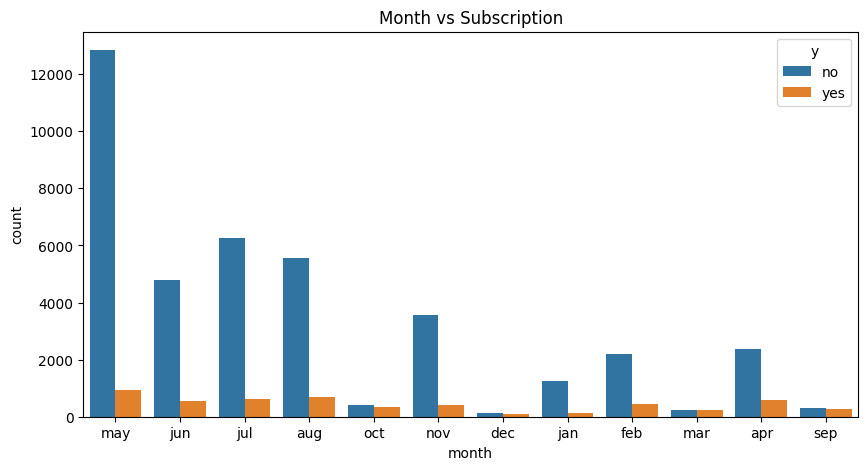

In [ ]:
# Subscription rates vary across months. Certain months show higher subscriptions,
# suggesting that the timing of marketing campaigns can influence customer response and effectiveness.
plt.figure(figsize=(10,5))
sns.countplot(x='month', hue='y', data=data)
plt.title("Month vs Subscription")
plt.show()

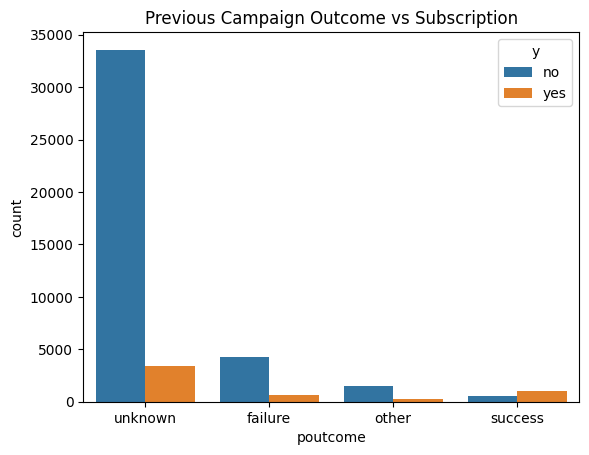

In [ ]:
# Customers with a successful previous campaign outcome are much more likely to subscribe,
# while those with failure or no prior contact show lower subscriptions.
# This highlights the importance of past campaign results in predicting customer response.
sns.countplot(x='poutcome', hue='y', data=data)
plt.title("Previous Campaign Outcome vs Subscription")
plt.show()

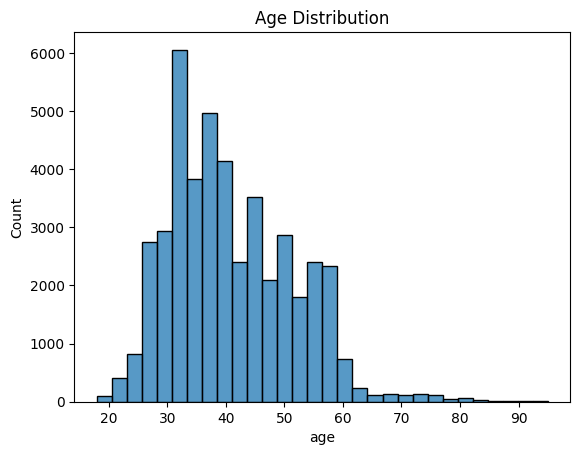

In [ ]:
# Most customers are in the [insert dominant age range from your graph] age group,
# indicating that the bank’s services mainly attract middle-aged adults.
# Age could be an important factor in targeting marketing campaigns.
sns.histplot(data['age'], bins=30)
plt.title("Age Distribution")
plt.show()

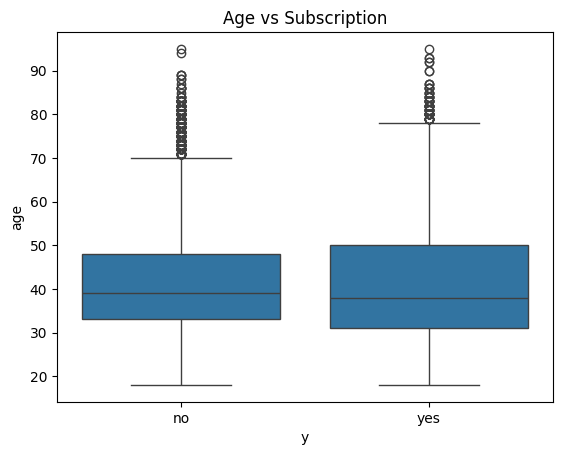

In [ ]:
# Customers who subscribe (yes) tend to be slightly older than non-subscribers (no),
#  suggesting that age may influence the likelihood of subscribing to the bank’s product.
sns.boxplot(x='y', y='age', data=data)
plt.title("Age vs Subscription")
plt.show()

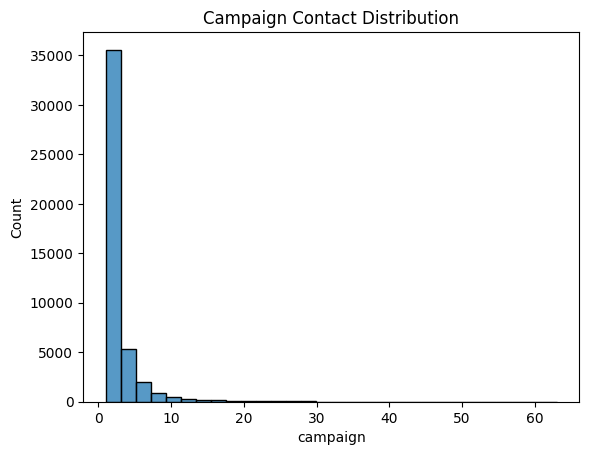

In [ ]:
# Most customers were contacted a few times, while very few were contacted many times.
# This suggests that excessive contact is rare and that targeting efficiency may vary with the number of contacts.
sns.histplot(data['campaign'], bins=30)
plt.title("Campaign Contact Distribution")
plt.show()

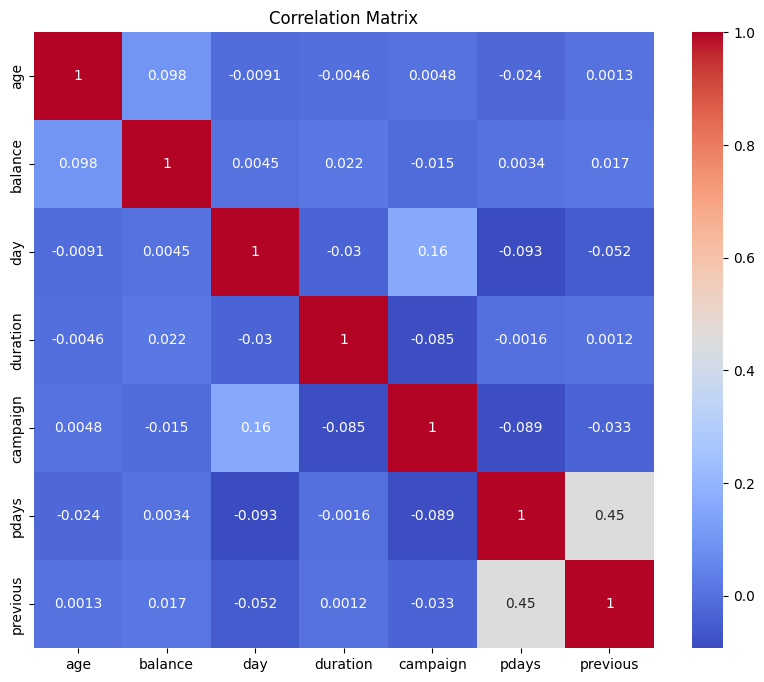

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

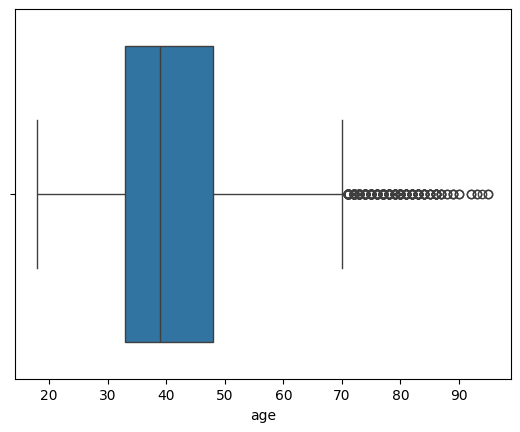

In [ ]:
sns.boxplot(x=data['age'])
plt.show()

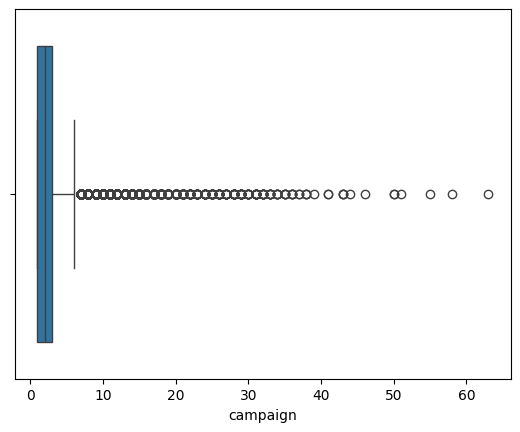

In [ ]:
sns.boxplot(x=data['campaign'])
plt.show()

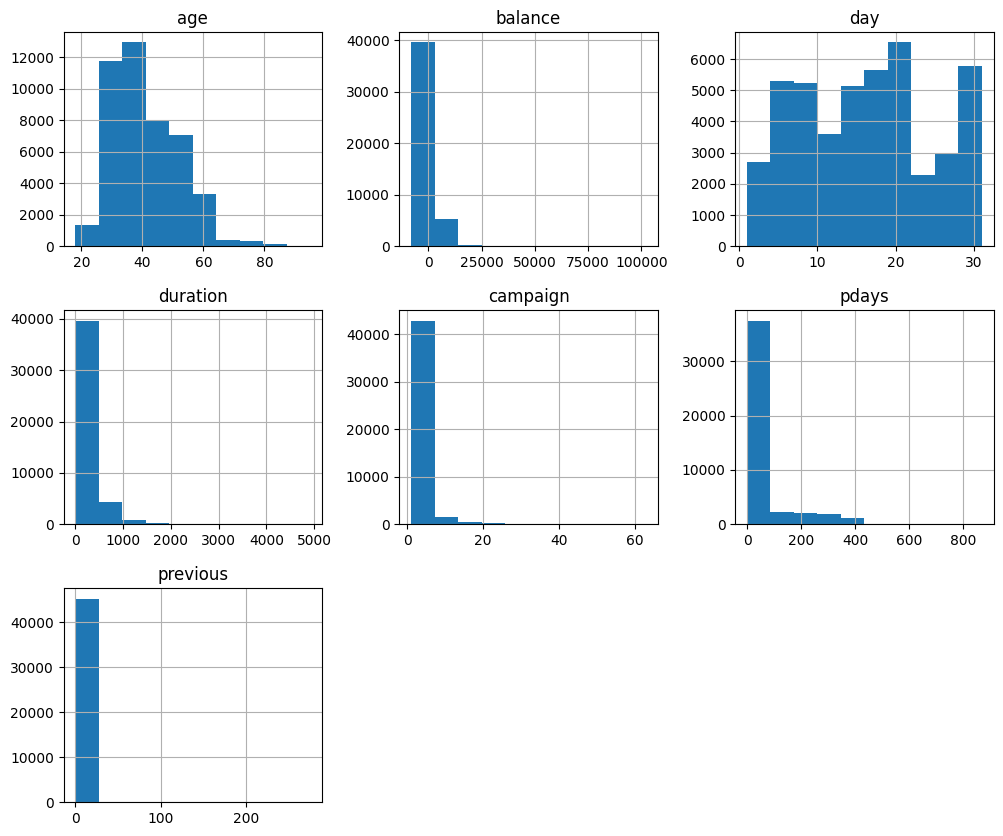

In [ ]:
# The histograms show the distribution of all numerical features.
# Most features are skewed, with some having outliers, indicating that data preprocessing (like scaling or outlier handling) may be needed before modeling.
data.hist(figsize=(12,10))
plt.show()

Data preprocessing


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()

# Step 1: Label Encoding
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# Step 2: One-Hot Encoding
data = pd.get_dummies(data,
                      columns=['job', 'marital', 'education', 'contact', 'month', 'poutcome'],
                      drop_first=True)

print(data.dtypes)

age                    int64
default                int64
balance                int64
housing                int64
loan                   int64
day                    int64
duration               int64
campaign               int64
pdays                  int64
previous               int64
y                      int64
job_blue-collar         bool
job_entrepreneur        bool
job_housemaid           bool
job_management          bool
job_retired             bool
job_self-employed       bool
job_services            bool
job_student             bool
job_technician          bool
job_unemployed          bool
job_unknown             bool
marital_married         bool
marital_single          bool
education_secondary     bool
education_tertiary      bool
education_unknown       bool
contact_telephone       bool
contact_unknown         bool
month_aug               bool
month_dec               bool
month_feb               bool
month_jan               bool
month_jul               bool
month_jun     

# CORRELATION

In [ ]:
data.corr()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
age,1.000000,-0.017879,0.097783,-0.185513,-0.015655,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.025155,-0.044002,0.021792,0.086650,-0.023571,0.447378,-0.008093,-0.065780,-0.197302,-0.068632,0.000412,0.050200,0.286257,-0.427817,-0.093979,-0.081629,0.069665,0.170349,-0.020132,0.073844,0.022872,-0.001198,-0.007466,0.002902,0.051768,0.019499,-0.127431,0.032775,0.060116,0.032418,-0.022967,0.035526,-0.000816
default,-0.017879,1.000000,-0.066745,-0.006025,0.077234,0.009424,-0.010021,0.016822,-0.029979,-0.018329,-0.022419,0.010341,0.026281,-0.000359,-0.002655,-0.011290,0.004107,0.000068,-0.016222,-0.003089,0.006470,-0.006669,-0.014460,0.003115,0.013220,-0.015239,-0.001236,-0.017208,0.019933,-0.007521,-0.009344,-0.009027,-0.006990,0.044257,0.007582,-0.013991,-0.002946,0.006129,-0.017454,-0.013953,-0.014445,-0.023344,0.039490
balance,0.097783,-0.066745,1.000000,-0.068768,-0.084350,0.004503,0.021560,-0.014578,0.003435,0.016674,0.052838,-0.048757,0.009642,0.001661,0.067797,0.046900,0.017850,-0.038151,0.001233,-0.016183,0.009023,0.010784,0.025708,-0.012537,-0.069937,0.084001,0.011181,0.037999,-0.037331,0.008605,0.021594,-0.003537,-0.024421,-0.064402,0.029566,0.023196,-0.071121,0.117254,0.040198,0.021922,0.008466,0.035240,-0.030271
housing,-0.185513,-0.006025,-0.068768,1.000000,0.041323,-0.027982,0.005075,-0.023599,0.124178,0.037076,-0.139173,0.177475,0.010600,-0.079380,-0.063382,-0.156633,-0.027319,0.070435,-0.085066,-0.012823,-0.048229,-0.075023,0.017681,-0.020475,0.101659,-0.099175,-0.047595,-0.080822,0.208409,-0.305641,-0.050556,-0.064523,-0.066448,-0.061231,-0.102298,-0.066284,0.427980,0.001152,-0.085439,-0.076343,0.039710,-0.091360,-0.063755
loan,-0.015655,0.077234,-0.084350,0.041323,1.000000,0.011370,-0.012412,0.009980,-0.022754,-0.011043,-0.068185,0.018291,0.039808,-0.017234,-0.038904,-0.014861,-0.007882,0.035575,-0.058503,0.014798,-0.035961,-0.031943,0.036906,-0.051716,0.070625,-0.045940,-0.049992,-0.013183,-0.007211,-0.069359,-0.020459,-0.008842,-0.004450,0.167764,-0.022749,-0.029761,-0.027867,0.019154,-0.030097,-0.033663,-0.009099,-0.053713,0.031406
day,-0.009120,0.009424,0.004503,-0.027982,0.011370,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.028348,-0.022898,-0.002312,0.003955,0.019021,-0.010123,0.005062,-0.006531,-0.015894,0.032517,-0.006382,-0.011199,0.007102,-0.007412,-0.005831,0.021730,0.000114,0.023652,-0.034103,0.030131,-0.011368,-0.283326,0.250523,0.147199,-0.193807,-0.020749,-0.025066,0.096080,0.030514,-0.053890,-0.032952,-0.030321,0.086256
duration,-0.004648,-0.010021,0.021560,0.005075,-0.012412,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.394521,0.009637,-0.001327,-0.008046,-0.008323,0.026032,0.007383,0.001427,-0.006504,-0.009176,0.020322,-0.006390,-0.022683,0.020328,0.002084,0.000891,-0.000682,-0.023201,-0.014379,-0.040054,0.019057,-0.009557,0.006989,0.016163,-0.021426,-0.005519,0.007089,-0.006041,0.015076,0.015077,-0.001958,0.042389,-0.003491
campaign,0.004760,0.016822,-0.014578,-0.023599,0.009980,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.073172,0.008986,0.002128,0.003097,0.016686,-0.030913,0.005479,-0.004671,-0.021813,0.020739,-0.018448,0.014091,0.031371,-0.023120,-0.020893,0.012866,0.005704,0.053895,0.004853,0.150378,-0.012635,-0.030747,-0.063064,0.104148,0.043893,-0.018612,-0.067551,-0.084697,-0.051031,-0.036718,-0.020107,-0.057486,0.107965
pdays,-0.023758,-0.029979,0.003435,0.124178,-0.022754,-0.093044,-0.001565,-0.088628,1.000000,0.454820,0.103621,0.020063,-0.014203,-0.031350,-0.007

In [ ]:
res=data.corr()

In [ ]:
res[res>0.8]

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
age,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pdays,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.dtypes

,0
age,int64
default,int64
balance,int64
housing,int64
loan,int64
day,int64
duration,int64
campaign,int64
pdays,int64
previous,int64


In [ ]:
data.isna().sum()

,0
age,0
default,0
balance,0
housing,0
loan,0
day,0
duration,0
campaign,0
pdays,0
previous,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
bool_cols = data.select_dtypes(include='bool').columns

data[bool_cols] = data[bool_cols].astype(int)

In [ ]:
data.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration',
       'campaign', 'pdays', 'previous', 'y', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown'],
      dtype='object')

In [ ]:
data.dtypes

,0
age,int64
default,int64
balance,int64
housing,int64
loan,int64
day,int64
duration,int64
campaign,int64
pdays,int64
previous,int64


In [ ]:
X = data.drop(['y','duration'], axis=1)
y = data['y']

OUTLIER

In [ ]:
# Create new feature
data['previously_contacted'] = data['pdays'].apply(lambda x: 0 if x == 999 else 1)

# Fix pdays
data['pdays'] = data['pdays'].apply(lambda x: 0 if x == 999 else x)

In [ ]:
num_cols = ['age','balance','campaign','pdays','previous']

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(col, "Outliers:", len(outliers))

age Outliers: 487
balance Outliers: 4729
campaign Outliers: 3064
pdays Outliers: 8257
previous Outliers: 8257


In [ ]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = np.where(data[col] > upper, upper,
                np.where(data[col] < lower, lower, data[col]))

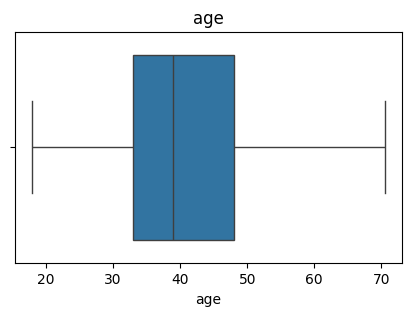

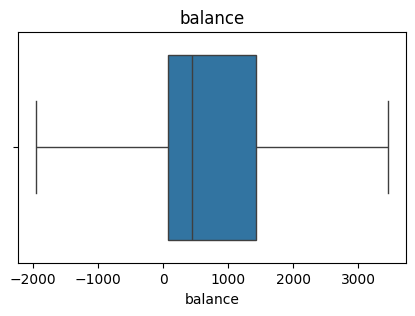

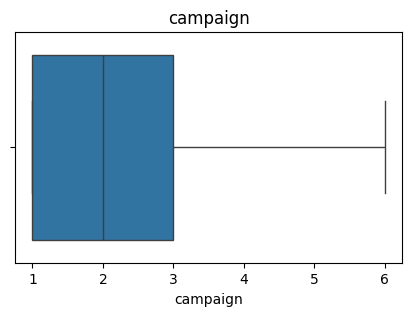

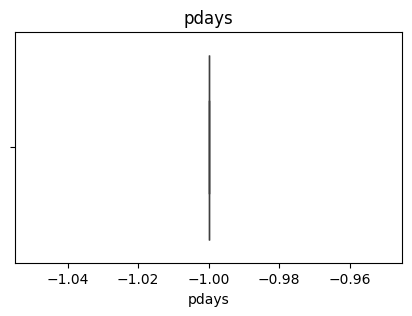

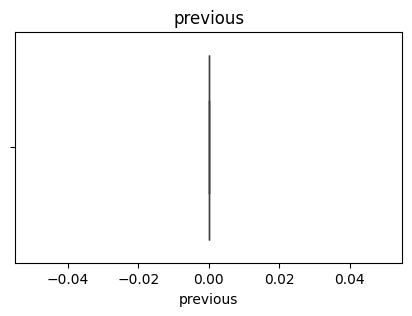

In [ ]:
num_cols = ['age','balance','campaign','pdays','previous']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

#SCALING :



we use robust scaling so ass it has lot of outlier

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

num_cols = ['age','balance','campaign','pdays','previous']

data[num_cols] = scaler.fit_transform(data[num_cols])

print(data.head())

        age  default   balance  housing  loan  day  duration  campaign  pdays  \
0  1.266667        0  1.250000        1     0    5       261      -0.5    0.0   
1  0.333333        0 -0.308997        1     0    5       151      -0.5    0.0   
2 -0.400000        0 -0.328909        1     1    5        76      -0.5    0.0   
3  0.533333        0  0.780236        1     0    5        92      -0.5    0.0   
4 -0.400000        0 -0.329646        0     0    5       198      -0.5    0.0   

   previous  y  job_blue-collar  job_entrepreneur  job_housemaid  \
0       0.0  0                0                 0              0   
1       0.0  0                0                 0              0   
2       0.0  0                0                 1              0   
3       0.0  0                1                 0              0   
4       0.0  0                0                 0              0   

   job_management  job_retired  job_self-employed  job_services  job_student  \
0               1       

In [ ]:
X.head(2)

,age,default,balance,housing,loan,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,1,-1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1
1,44,0,29,1,0,5,1,-1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1


In [ ]:
X.tail(1)

,age,default,balance,housing,loan,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
45210,37,0,2971,0,0,17,2,188,11,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0


In [ ]:
X.shape

(45211, 41)

Model creation


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
rf_params = {
    'n_estimators': [100, 200],   # not 1000+
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

class_weights = {0:1, 1:4}

rf = RandomForestClassifier(
    class_weight=class_weights,  # ✅ here
    random_state=42
)

rf_rand = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

rf_rand.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight={0: 1, 1: 4},
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   random_state=42, scoring='f1')

In [ ]:
print("Best Params:", rf_rand.best_params_)

y_pred = rf_rand.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7952
           1       0.50      0.41      0.45      1091

    accuracy                           0.88      9043
   macro avg       0.71      0.68      0.69      9043
weighted avg       0.87      0.88      0.87      9043



In [ ]:
from sklearn.metrics import accuracy_score

y_pred = rf_rand.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.8793541966161672


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(scale_pos_weight=7952/1091)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# compute weight
scale_pos_weight = 7952 / 1091

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:58:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8305871945150946
Confusion Matrix:
 [[6881 1071]
 [ 461  630]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90      7952
           1       0.37      0.58      0.45      1091

    accuracy                           0.83      9043
   macro avg       0.65      0.72      0.68      9043
weighted avg       0.87      0.83      0.85      9043



In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=12,  #  increase from ~7 → try 10–15
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# compute weights based on imbalance
sample_weights = compute_sample_weight(
    class_weight={0:1, 1:8},   #  tune this (5–10 range)
    y=y_train
)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_gb = gb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy: 0.796195952670574
Confusion Matrix:
 [[6499 1453]
 [ 390  701]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88      7952
           1       0.33      0.64      0.43      1091

    accuracy                           0.80      9043
   macro avg       0.63      0.73      0.65      9043
weighted avg       0.87      0.80      0.82      9043



In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.25, 0.2]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.05, 0.03],
    'max_depth': [3, 4, 5]
}

gb_rand = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

gb_rand.fit(X_train, y_train, sample_weight=sample_weights)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.05, 0.03],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1')

In [ ]:
y_probs = gb_model.predict_proba(X_test)[:, 1]


for t in [0.5, 0.7, 0.8, 0.6, 0.9]:
    y_pred_t = (y_probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))
    print()


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      7952
           1       0.33      0.64      0.43      1091

    accuracy                           0.80      9043
   macro avg       0.63      0.73      0.65      9043
weighted avg       0.87      0.80      0.82      9043



Threshold: 0.7
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7952
           1       0.50      0.47      0.49      1091

    accuracy                           0.88      9043
   macro avg       0.72      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



Threshold: 0.8
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.55      0.36      0.43      1091

    accuracy                           0.89      9043
   macro avg       0.73      0.66      0.69      9043
weighted avg       0.87 

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

y_pred = rf_rand.predict(X_test)

# probabilities
y_probs_rf = rf_rand.predict_proba(X_test)[:, 1]   # if using RandomizedSearchCV
# or: y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.7, 0.8, 0.6, 0.9]:
    y_pred_t = (y_probs_rf > t).astype(int)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(f"\nRF Threshold: {t}")
    print(classification_report(y_test, y_pred_t))

Accuracy: 0.8793541966161672

RF Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7952
           1       0.50      0.41      0.45      1091

    accuracy                           0.88      9043
   macro avg       0.71      0.68      0.69      9043
weighted avg       0.87      0.88      0.87      9043

Accuracy: 0.8793541966161672

RF Threshold: 0.7
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.72      0.18      0.29      1091

    accuracy                           0.89      9043
   macro avg       0.81      0.59      0.62      9043
weighted avg       0.88      0.89      0.86      9043

Accuracy: 0.8793541966161672

RF Threshold: 0.8
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      7952
           1       0.75      0.13      0.22      1091

    accuracy                          

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# create model
xgb_model = XGBClassifier()

# fit model
xgb_model.fit(X_train, y_train)

# now predict
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.7, 0.8, 0.6, 0.9]:
    y_pred = (y_probs_xgb >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.61      0.25      0.36      1091

    accuracy                           0.89      9043
   macro avg       0.76      0.62      0.65      9043
weighted avg       0.87      0.89      0.87      9043


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      7952
           1       0.71      0.13      0.22      1091

    accuracy                           0.89      9043
   macro avg       0.80      0.56      0.58      9043
weighted avg       0.87      0.89      0.85      9043


Threshold: 0.8
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7952
           1       0.75      0.08      0.15      1091

    accuracy                           0.89      9043
   macro avg       0.82      0.54      0.54      9043
weighted avg       0.87   

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight={0:1, 1:3},  # you used this earlier
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight={0: 1, 1: 3}, max_iter=1000, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)


Logistic Regression Accuracy: 0.883777507464337


In [ ]:
from sklearn.metrics import accuracy_score

# Logistic Regression
y_pred_lr =lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# Random Forest (use best estimator if using RandomizedSearchCV)
y_pred_rf = rf_rand.predict(X_test)   # or rf_model
acc_rf = accuracy_score(y_test, y_pred_rf)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

# Gradient Boosting
y_pred_gb = gb_model.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

print("Logistic Regression Accuracy:", acc_lr)
print("Random Forest Accuracy:", acc_rf)
print("XGBoost Accuracy:", acc_xgb)
print("Gradient Boosting Accuracy:", acc_gb)

Logistic Regression Accuracy: 0.883777507464337
Random Forest Accuracy: 0.8793541966161672
XGBoost Accuracy: 0.8900807254229791
Gradient Boosting Accuracy: 0.796195952670574


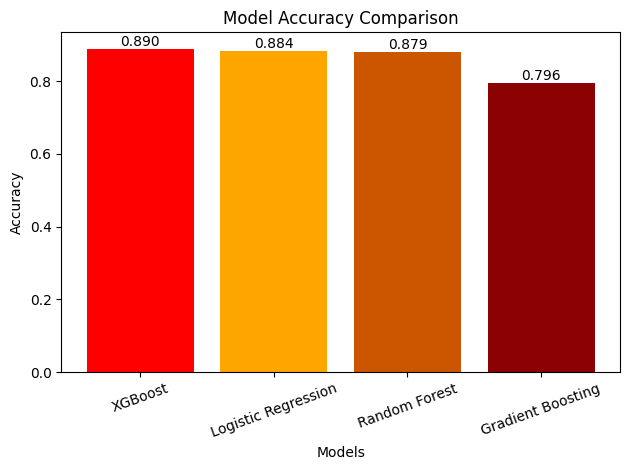

In [ ]:
import matplotlib.pyplot as plt

# Data
models = ["Logistic Regression", "Random Forest", "XGBoost", "Gradient Boosting"]
accuracies = [0.883777507464337, 0.8793541966161672, 0.8900807254229791, 0.796195952670574]

# Sort by accuracy (descending)
models, accuracies = zip(*sorted(zip(models, accuracies), key=lambda x: x[1], reverse=True))

# Custom colors (red → orange → burnt orange → dark red)
colors = ["red", "orange", "#cc5500", "#8b0000"]

plt.figure()

bars = plt.bar(models, accuracies, color=colors)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# KEY challenge

The major issue in the Portuguese Bank dataset was class imbalance. Since the class weights were biased, I used threshold adjustment and imbalance-handling techniques to ensure the model learned effectively.

The dataset contained many object-type categorical variables. I handled this by converting binary categories to boolean and applying one-hot encoding to the rest, which improved the model’s ability to learn.

Default probability threshold (0.5) did not give the best recall, so threshold tuning was necessary.